# House Prices - Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

### Why this matters

- **Reproducible plots** — `sns.set_theme(...)` fixes the visual style so every chart in this notebook (and any teammate re-running it) looks the same, instead of depending on whatever matplotlib's default style happens to be.
- **`display.max_columns`** — this dataset has 81 columns. Without raising this option, pandas truncates `.head()` / `.describe()` output with `...`, hiding features you actually need to inspect. A small setting, but a common trap for anyone new to wide tabular datasets.

In [2]:
train = pd.read_csv("dataset/train.csv")
test = pd.read_csv("dataset/test.csv")

print(f"train shape: {train.shape}")
print(f"test shape: {test.shape}")
train.head()

train shape: (1460, 81)
test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Why this matters

- **Train/test asymmetry** — `train` has 81 columns, `test` has 80. The missing one is `SalePrice`, the target we're predicting. Any feature engineering done below must be applied identically to both frames, since the end goal is producing predictions for `test`.
- **`Id` is not a feature** — it's a row identifier for submission purposes only. Left in a feature matrix, a model can pick up on it as spurious noise (or worse, as an accidental proxy for row order). It's dropped explicitly in the baseline model further down, but it's an easy column to forget in general.
- **Mixed feature types, visible from `.head()` alone** — this dataset needs at least three different encoding strategies:
    - **Continuous numeric** — `LotArea`, `GrLivArea`, `SalePrice`
    - **Ordinal, encoded as text** — `ExterQual`, `BsmtQual`, `KitchenQual`: values like `Ex`, `Gd`, `TA`, `Fa`, `Po` have a real order that a plain one-hot encoder would throw away
    - **Nominal categorical** — `Neighborhood`, `RoofStyle`, `SaleType`: no inherent order, well suited to one-hot or target encoding
- **`NaN` can mean "doesn't apply," not "unknown"** — `Alley` is `NaN` for most of these rows. Per the data dictionary that means "no alley access," not missing data. This distinction — structurally absent vs. genuinely unknown — is one of the most important judgment calls in this dataset, and comes back in the missing-values section below.

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

### Why this matters

- **Dtype tells you the encoding job ahead** — `dtypes: float64(3), int64(35), str(43)`. Every one of those 43 `str` columns needs some form of encoding (one-hot, ordinal, target/frequency) before most models — including the RandomForest baseline built later — can use it. Right now that baseline only uses the numeric columns, silently discarding over half the dataset's columns.
- **`float64` is often a missing-value tell, not a design choice** — `LotFrontage`, `MasVnrArea`, and `GarageYrBlt` are stored as `float64` even though they represent whole numbers (or years). Pandas silently upcasts an int column to float the moment it contains a `NaN`, since integer arrays can't hold `NaN`. Seeing a "should-be-int" column as `float64` is a fast way to spot missingness without running `.isnull()`.
- **Non-null counts double as a missing-value preview** — e.g. `PoolQC` shows only 7 non-null out of 1460 rows. That one line already foreshadows the dedicated missing-values table two cells down.

In [4]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1379.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,1057.429452,1162.626712,346.992466,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,6.517808,0.613014,1978.506164,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,438.705324,386.587738,436.528436,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,1.625393,0.644666,24.689725,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,795.750000,882.000000,0.000000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,991.500000,1087.000000,0.000000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1980.000000,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,1391.250000,728.000000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,4692.000000,2065.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,14.000000,3.000000,2010.000000,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Why this matters

- **Wildly different scales** — `LotArea` ranges up to 215,245 while `OverallQual` only ranges 1–10. Distance- or gradient-based models (KNN, SVR, regularized linear regression, neural nets) need these scaled (e.g. `StandardScaler`) or they'll implicitly weight `LotArea` far more heavily just because its numbers are bigger. Tree-based models like the RandomForest baseline below are scale-invariant, so this matters more for future experiments than for the current model.
- **Outlier hints from max vs. 75th percentile** — `LotArea`'s 75th percentile is ~11,600 but its max is 215,245. That jump is worth visualizing (e.g. a scatterplot against `SalePrice`) before trusting a linear model, since a handful of extreme lots can dominate a least-squares fit.
- **Zero-inflated features** — `PoolArea`, `MiscVal`, `3SsnPorch`, and `ScreenPorch` all have a median *and* 75th percentile of 0 — meaning at least 75% of houses have none of these. These are good candidates for a binary "has X" feature (e.g. `HasPool = PoolArea > 0`) rather than feeding in the raw continuous value, since the real signal is mostly "present vs. absent."
- **`describe()` only covers numeric columns** — the 43 categorical columns (`Neighborhood`, `KitchenQual`, etc.) are silently excluded here. `train.describe(include="object")` or `.value_counts()` on individual columns is how you'd profile those instead.

## Missing values

In [5]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageType,81,5.5
GarageYrBlt,81,5.5
GarageFinish,81,5.5


### Why this matters

- **Most of this "missing" data isn't actually missing** — per the competition's data dictionary, `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`, and the `Garage*`/`Bsmt*` columns use `NaN` to mean the feature doesn't exist for that house (no pool, no alley, no garage, no basement) — not "value unknown." The correct fix for these is `fillna("None")`, not statistical imputation: imputing a basement-quality score for a house with no basement would invent information that isn't there.
- **A much smaller set is genuinely missing and needs real imputation** — `LotFrontage` (17.7%), `MasVnrArea` (0.5%), and `Electrical` (0.1%, a single row) are the columns where "unknown" really is the right interpretation. `LotFrontage` is commonly imputed per-`Neighborhood` median, since street frontage correlates strongly with local lot layout, rather than one global median.
- **Missingness itself can be a feature** — with `PoolQC` at 99.5% missing, a derived binary flag like `HasPool` is usually more useful to a model than the raw categorical quality value, which has almost no non-missing rows to learn a pattern from.
- **How this connects to the baseline model below** — that model sidesteps all of this nuance by using only numeric columns and imputing every gap with the column median, correct or not (e.g. a missing `GarageYrBlt`, which means "no garage," gets replaced with a *typical build year*, which is misleading). That's a reasonable simplification for a first pipeline smoke-test, but not a final approach.

## Target: SalePrice

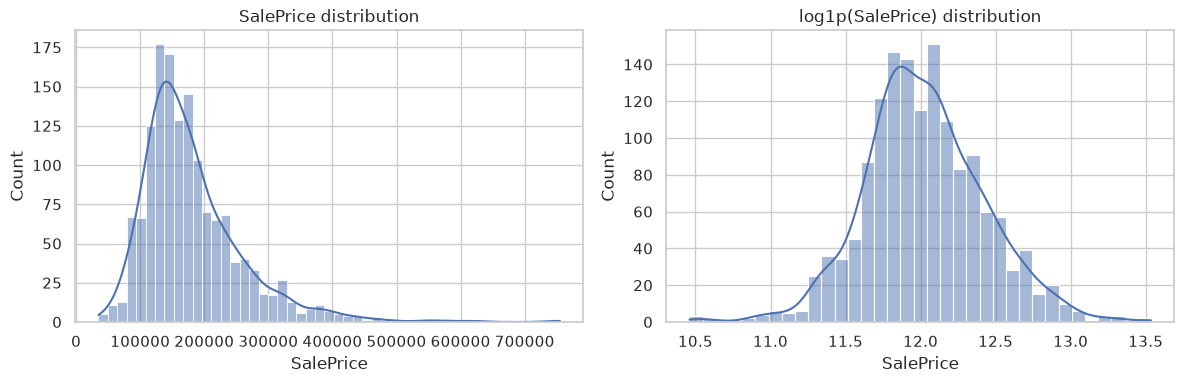

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice distribution")

sns.histplot(np.log1p(train["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice) distribution")

plt.tight_layout()
plt.show()

train["SalePrice"].describe()

### Why this matters

- **The target is right-skewed** — most homes cluster in the \$100k–\$250k range, but a long tail of expensive homes stretches the distribution out. That skew violates the assumption of normally-distributed residuals that ordinary least squares (and several of its error metrics) relies on.
- **Why `log1p` specifically, not just `log`** — `np.log1p(x)` computes `log(1 + x)`, which stays defined at `x = 0` (plain `log(0)` is `-inf`). `SalePrice` is always positive here, so this particular safety net isn't strictly required, but `log1p`/`expm1` is the standard idiom for log-transforming a target because it generalizes safely to data that might include zeros.
- **The payoff is in the right-hand panel** — `log1p(SalePrice)` looks close to a normal (bell-shaped) distribution. Many models — especially linear ones — perform better, and their error metrics become more meaningful, when trained to predict `log1p(SalePrice)` and transformed back with `np.expm1()` afterward. It's also why this competition scores submissions on RMSLE (root mean squared **log** error) rather than raw RMSE: it's judging errors on the same log scale shown here.
- **A modeling choice this notebook doesn't take (yet)** — the baseline model below trains directly on raw `SalePrice`, not the log-transformed version. Comparing the two is a natural next experiment.

## Correlation with SalePrice

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


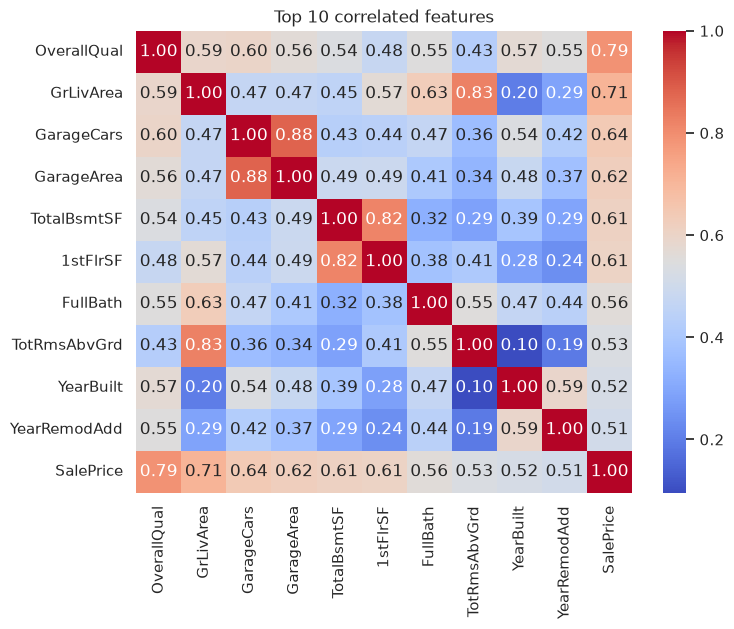

In [7]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr = train[numeric_cols].corr()["SalePrice"].sort_values(ascending=False)
top_features = corr.index[1:11]

print(corr.head(11))

plt.figure(figsize=(8, 6))
sns.heatmap(train[top_features.tolist() + ["SalePrice"]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 10 correlated features")
plt.show()

### Why this matters

The correlation heatmap is a fast way to prioritize which of the 80+ features are actually worth building on:

- **Feature selection / prioritization** — `OverallQual` (0.79) and `GrLivArea` (0.71) are far more predictive of `SalePrice` than most other columns. When time or model complexity is limited, these are the first features to keep.
- **Spotting redundancy (multicollinearity)** — `GarageCars` and `GarageArea` move almost identically (both describe garage size). Feeding both into a linear model inflates coefficient variance and makes them individually unstable, even though the model's overall predictions may still be fine. Tree-based models like the RandomForest below are largely unaffected by this, but it's still useful to know before engineering new features on top of them.
- **Sanity-checking the data** — a variable you *expect* to matter (e.g. total square footage) showing near-zero correlation is a signal to check for data issues, or that its relationship with price is non-linear rather than absent.
- **A cheap baseline before modeling** — comparing correlation strength against the RandomForest's `feature_importances_` later is a good gut-check: if the two disagree sharply, it often means non-linear interactions the correlation matrix can't see.

**Limitation to keep in mind:** these are Pearson correlations, so they only capture *linear* relationships. A feature with a strong curved relationship to price (e.g. diminishing returns on lot size) can show a low correlation here while still being highly predictive.

## Baseline model

Quick sanity-check model using only numeric features with median imputation — not tuned, just to confirm the pipeline works end-to-end.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

feature_cols = [c for c in numeric_cols if c not in ("Id", "SalePrice")]
X = train[feature_cols]
y = train["SalePrice"]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_valid_imp = imputer.transform(X_valid)

model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train_imp, y_train)

preds = model.predict(X_valid_imp)
rmse = mean_squared_error(y_valid, preds) ** 0.5
print(f"Validation RMSE: {rmse:,.0f}")

Validation RMSE: 29,319


### Why this matters

- **This model only sees 36 of 81 columns** — `feature_cols` is `numeric_cols` minus `Id` and `SalePrice`. Every categorical feature (`Neighborhood`, `KitchenQual`, `ExterQual`, etc.) is invisible to it, even though several are known from domain knowledge to be strong price predictors. This RMSE is a floor, not a ceiling — encoding the categoricals is the single highest-leverage next step.
- **Median imputation here is a placeholder, not a final answer** — as the missing-values section above explains, gaps in `GarageYrBlt`, `MasVnrArea`, etc. usually mean "this feature doesn't exist for this house," not "unknown value." Median-imputing a plausible-looking `GarageYrBlt` for a house with no garage manufactures information that isn't real. Fine for a first smoke-test of the pipeline; worth revisiting before trusting the model.
- **Why a `RandomForestRegressor` for a baseline** — tree-based models handle unscaled features and non-linear relationships without any preprocessing beyond imputation, making them a convenient way to confirm a modeling pipeline runs end-to-end before investing in more careful feature engineering or a more preprocessing-sensitive model (e.g. regularized linear regression, which needs scaling and one-hot encoding first).
- **A natural next diagnostic** — `model.feature_importances_`, paired with `feature_cols`, shows which numeric columns this model actually relied on. It's worth comparing against the correlation ranking earlier in the notebook: strong agreement is reassuring, while disagreement usually flags a non-linear relationship that a Pearson correlation can't see.